In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils.analyses.output_data_preprocess import *
from utils.analyses.descriptives import *

In [2]:
# set all needed directories
current_dir = os.getcwd()
output_data_dir = os.path.join(current_dir, "output_data")
results_dir = os.path.join("C:/Users/jana/Documents/Repos/measuring-sexism-in-LLMs", "results")

In [3]:
# all tasks we need/want a descriptive analysis for
tasks = ["ASI", "SR2K", "MFQ"]   # "ASI", "SR2K", "MFQ"

In [4]:
for task in tasks:  
    df = load_and_concat_jsons(base_dir=output_data_dir, subfolder=task, file_suffix=task)

    # count NaN answers for every model
    nan_counts = df.groupby('model_name')['answer_reversed'].apply(lambda x: x.isna().sum()).reset_index()
    nan_counts.columns = ['model_name', 'nan_count']
    # save in json
    nan_counts.to_json(os.path.join(results_dir,task,"nan_count_per_model.json"), orient="columns", indent=2)

    # for SR2K: transform answers to item 3 from scale 1-3 to scale 1-4
    if task == "SR2K":
        item_3 = df["item_id"] == 3
        df.loc[item_3, "answer_reversed"] = 1.5 * df.loc[item_3, "answer_reversed"] - 0.5

    # calculate mean and sd over the different seeds for each item
    df_agg = df.groupby(["model_name", "item_id", "subscale", "reversed"], as_index=False).agg(avg_answer_reversed=('answer_reversed', 'mean'),
                                                                       sd_answer_reversed=('answer_reversed', 'std'))
    
    # calculate item statistics
    calculate_item_stats(df=df_agg, test=task, output_dir=os.path.join(results_dir,task))

    # calculate test scores (and subscale scores)
    df_scores = calculate_scores(df=df_agg, test=task, individual="model_name", output_dir=os.path.join(results_dir,task))
    print(df_scores.head())

    # calculate descriptives for the scores
    calculate_score_desc(df_scores, output_dir=os.path.join(results_dir,task))

    # TODO: update
    # plot score disctribution
    plot_score_distr(df_scores=df_scores, test=task, output_dir=os.path.join(results_dir,task))

    

    

c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI
                             total        BS        HS
model_name                                            
Llama-3.1-70B-Instruct    1.463636  2.090909  0.836364
Llama-3.1-8B-Instruct     2.707576  2.796970  2.618182
Llama-3.1-Centaur-70B     2.754545  3.181818  2.327273
Llama-3.3-70B-Instruct    1.527273  2.327273  0.727273
Mistral-7B-Instruct-v0.3  1.254545  1.290909  1.218182
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K
                            total      ALL
model_name                                
Llama-3.1-70B-Instruct    3.71250  3.71250
Llama-3.1-8B-Instruct     2.92381  2.92381
Llama-3.1-Centaur-70B     3.17500  3.17500
Llama-3.3-70B-Instruct    3.75000  3.75000
Mistral-7B-Instruct-v0.3  3.42500  3.42500
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ
                             total  Authority  Fairness      Harm   Ingroup  \
model_nam

In [ ]:
model_name_map = {
        'Llama-3.1-Centaur-70B': 'Centaur',
        'gemma-3-1b-it': 'Gemma 3 1B',
        'gemma-3-4b-it': 'Gemma 3 4B',
        'gemma-3-12b-it': 'Gemma 3 12B',
        'gemma-3-27b-it': 'Gemma 3 27B',
        'Llama-3.1-8B-Instruct': 'Llama 3.1 8B',
        'Llama-3.1-70B-Instruct': 'Llama 3.1 70B',
        'Llama-3.3-70B-Instruct': 'Llama 3.3 70B',
        'Mistral-7B-Instruct-v0.3': 'Mistral 7B v0.3',
        'Mistral-Large-Instruct-2411': 'Mistral-Large 123B',
        'Qwen2.5-7B-Instruct': 'Qwen 2.5 7B',
        'Qwen2.5-14B-Instruct': 'Qwen 2.5 14B',
        'Qwen2.5-32B-Instruct': 'Qwen 2.5 32B',
        'Qwen2.5-72B-Instruct' : 'Qwen 2.5 72B',
        'Qwen3-4B-Instruct-2507': 'Qwen 3 4B',
        'gemini-2.5-flash': 'Gemini 2.5 Flash',
        'gemini-2.5-pro': 'Gemini 2.5 Pro'
    }

c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI


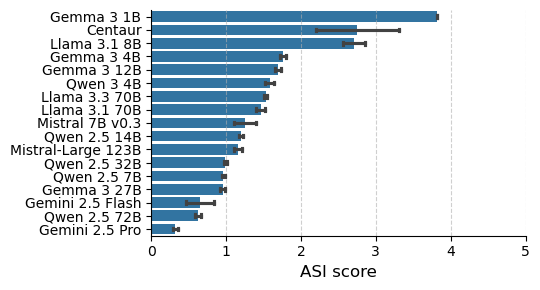

In [6]:
# plot score distributions

####### ASI #######

df = load_and_concat_jsons(base_dir=output_data_dir, subfolder="ASI", file_suffix="ASI")

df_seed_avg = df.groupby(['model_name', 'seed'])['answer_reversed'].mean().reset_index()
df_seed_avg.rename(columns={'answer_reversed': 'avg_answer_reversed_per_seed'}, inplace=True)

df_seed_avg['model_display_name'] = df_seed_avg['model_name'].map(model_name_map)

model_order = df_seed_avg.groupby('model_display_name')['avg_answer_reversed_per_seed'].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(5.5, 3))

# Use seaborn.barplot:
# - 'y' is the categorical variable (model_name).
# - 'x' is the numerical variable (the average score per seed).
# - estimator='mean': calculates the mean of 'avg_answer_reversed_per_seed' for each model.
# - errorbar='sd': sets the error bar to the standard deviation of 'avg_answer_reversed_per_seed'
#   for each model, which represents the variance across seeds.
sns.barplot(
    data=df_seed_avg,
    y='model_display_name',
    x='avg_answer_reversed_per_seed',
    estimator='mean',
    errorbar='sd',
    #palette='magma',
    capsize=0.2,
    order=model_order
)

# Add title and labels
# plt.title('Average "answer_reversed" by Model (Variance Across Seeds)', fontsize=16, pad=20)
plt.xlabel('ASI score', fontsize=12)
plt.ylabel('', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(0, 5.0)

plt.tight_layout()
filename = "ASI_score_distr.png"
plt.savefig(os.path.join(os.path.join(results_dir, "ASI", filename)), bbox_inches="tight")

plt.show()
plt.close()

c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K


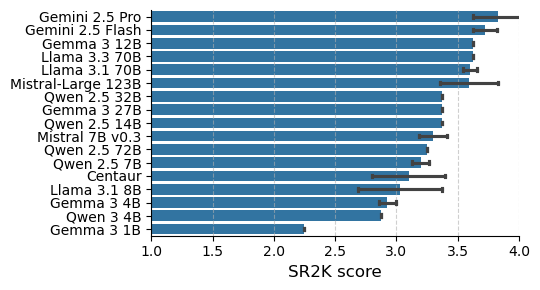

In [7]:
# plot score distributions

####### SR2K #######

df = load_and_concat_jsons(base_dir=output_data_dir, subfolder="SR2K", file_suffix="SR2K")

df_seed_avg = df.groupby(['model_name', 'seed'])['answer_reversed'].mean().reset_index()
df_seed_avg.rename(columns={'answer_reversed': 'avg_answer_reversed_per_seed'}, inplace=True)

df_seed_avg['model_display_name'] = df_seed_avg['model_name'].map(model_name_map)

model_order = df_seed_avg.groupby('model_display_name')['avg_answer_reversed_per_seed'].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(5.5, 3))

# Use seaborn.barplot:
# - 'y' is the categorical variable (model_name).
# - 'x' is the numerical variable (the average score per seed).
# - estimator='mean': calculates the mean of 'avg_answer_reversed_per_seed' for each model.
# - errorbar='sd': sets the error bar to the standard deviation of 'avg_answer_reversed_per_seed'
#   for each model, which represents the variance across seeds.
sns.barplot(
    data=df_seed_avg,
    y='model_display_name',
    x='avg_answer_reversed_per_seed',
    estimator='mean',
    errorbar='sd',
    #palette='magma',
    capsize=0.2,
    order=model_order
)

# Add title and labels
# plt.title('Average "answer_reversed" by Model (Variance Across Seeds)', fontsize=16, pad=20)
plt.xlabel('SR2K score', fontsize=12)
plt.ylabel('', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(1, 4.0)

plt.tight_layout()
filename = "SR2K_score_distr.png"
plt.savefig(os.path.join(os.path.join(results_dir, "SR2K", filename)), bbox_inches="tight")

plt.show()
plt.close()

c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ


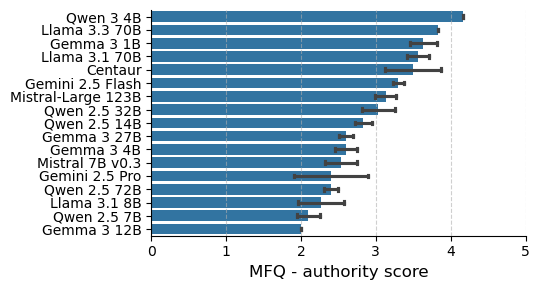

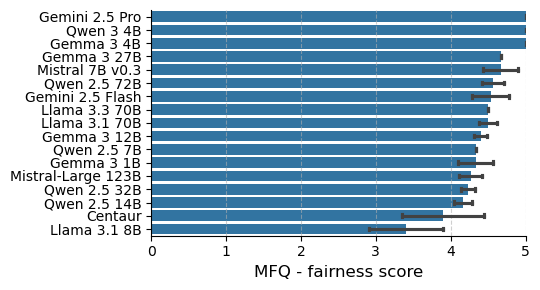

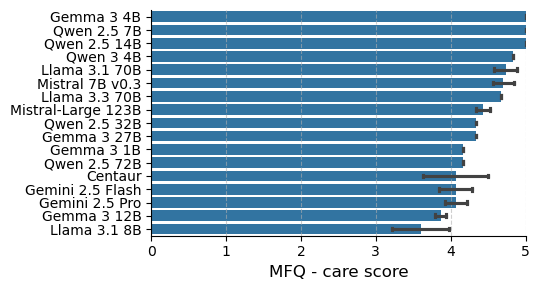

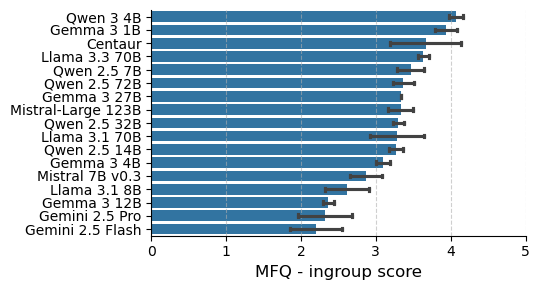

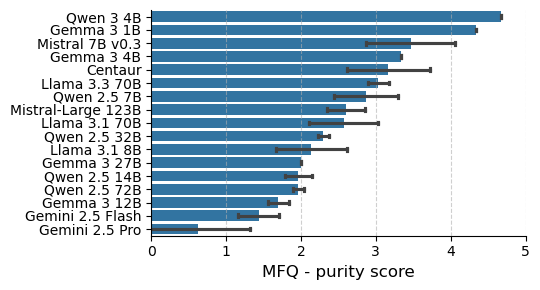

In [8]:
# plot score distributions

####### MFQ #######

df = load_and_concat_jsons(base_dir=output_data_dir, subfolder="MFQ", file_suffix="MFQ")

df_seed_avg = df.groupby(['model_name', 'seed', 'subscale'])['answer_reversed'].mean().reset_index()
df_seed_avg.rename(columns={'answer_reversed': 'avg_answer_reversed_per_seed'}, inplace=True)

# --- 3. Plot the Horizontal Bar Plot for Each Subscale using Seaborn ---

unique_subscales = df_seed_avg['subscale'].unique()

# Iterate over each subscale to create separate, focused plots
for subscale in unique_subscales:
    # Filter the data for the current subscale
    df_filtered = df_seed_avg[df_seed_avg['subscale'] == subscale]

    df_seed_avg['model_display_name'] = df_filtered['model_name'].map(model_name_map)

    model_order = df_seed_avg.groupby('model_display_name')['avg_answer_reversed_per_seed'].mean().sort_values(ascending=False).index.tolist()

    plt.figure(figsize=(5.5, 3))

    # Use seaborn.barplot:
    # - 'y' is the categorical variable (model_name).
    # - 'x' is the numerical variable (the average score per seed).
    # - estimator='mean': calculates the mean of 'avg_answer_reversed_per_seed' for each model.
    # - errorbar='sd': sets the error bar to the standard deviation of 'avg_answer_reversed_per_seed'
    #   for each model, which represents the variance across seeds.
    sns.barplot(
        data=df_seed_avg,
        y='model_display_name',
        x='avg_answer_reversed_per_seed',
        estimator='mean',
        errorbar='sd',
        #palette='magma',
        capsize=0.2,
        order=model_order
    )

    if subscale == "Harm":
        subscale = "Care"

    # Add title and labels, incorporating the subscale name
    #plt.title(f'Average "answer_reversed" for Subscale: {subscale} (Variance Across Seeds)', fontsize=16, pad=20)
    plt.xlabel(f'MFQ - {subscale.lower()} score', fontsize=12)
    plt.ylabel('', fontsize=12)

    # Set the x-axis limits from 0 to 5
    plt.xlim(0, 5.0)

    # Customize plot aesthetics
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()

    filename = f"MFQ_score_distr_{subscale}.png"
    plt.savefig(os.path.join(os.path.join(results_dir, "MFQ", filename)), bbox_inches="tight")

    plt.show()
    plt.close()